In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import (
    mean_absolute_error,      
    mean_squared_error,       
    root_mean_squared_error,  
    r2_score,                 
    mean_absolute_percentage_error,  
    accuracy_score,           
    f1_score,                 
    confusion_matrix,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV

In [3]:
url = r"C:\Users\andre\Downloads\archive (1)\used_cars.csv"
cars = pd.read_csv(url)

In [4]:
cars.shape

(4009, 12)

In [5]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB


In [6]:
cars.isnull().sum()

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Из приведённого ниже анализа мы видим, что все машины, у которых стоит NaN в главе fuel_type - они являются электрическими, это показывает также приведённый ниже датасет, где в графе engine стоит - Electric либо Motor Electric, в связи с этим я заменил все NaN на electric

In [7]:
electric_brands = ['Lucid', 'Tesla', 'Rivian', 'Polestar', 'Karma']
print(cars[cars['brand'].isin(electric_brands)][['fuel_type']])

     fuel_type
9          NaN
44         NaN
68         NaN
92         NaN
122        NaN
...        ...
3906       NaN
3908       NaN
3913       NaN
3932       NaN
3961       NaN

[110 rows x 1 columns]


In [8]:
cars[(~cars['brand'].isin(electric_brands)) & (cars['fuel_type'].isna())]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
253,Mercedes-Benz,EQS 450 4MATIC,2023,"7,388 mi.",NaN,355.0HP Electric Motor Electric Fuel System,1-Speed A/T,Gray,Beige,None reported,Yes,"$105,500"
266,Mercedes-Benz,EQS 450+ Base,2022,"16,238 mi.",NaN,329.0HP Electric Motor Electric Fuel System,1-Speed A/T,White,Beige,None reported,Yes,"$62,479"
321,Chevrolet,Bolt EUV Premier,2022,"7,624 mi.",NaN,Electric,1-Speed Automatic,Mosaic Black Metallic,Jet Black,None reported,Yes,"$31,985"
383,Ford,Mustang Mach-E Select,2023,923 mi.,NaN,Standard Range Battery,Automatic,Rapid Red Metallic Tinted Clearcoat,Black Onyx,None reported,NaN,"$46,998"
451,Audi,e-tron Prestige,2019,"33,012 mi.",NaN,355.0HP Electric Motor Electric Fuel System,1-Speed A/T,Blue,Beige,None reported,Yes,"$38,000"
456,Kia,EV6 Wind,2022,"11,945 mi.",NaN,111.2Ah / FR 70kW / RR 160kW (697V),Automatic,Glacier,Black,None reported,NaN,"$38,998"
503,Chevrolet,Bolt EUV Premier,2022,"14,676 mi.",NaN,200.0HP Electric Motor Electric Fuel System,A/T,Black,Blue,None reported,Yes,"$33,000"
542,Nissan,Leaf S,2018,"56,450 mi.",NaN,147.0HP Electric Motor Electric Fuel System,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$13,999"
543,Nissan,Leaf SL,2012,"102,000 mi.",NaN,107.0HP Electric Motor Electric Fuel System,1-Speed A/T,Silver,Gray,None reported,Yes,"$4,200"
684,Audi,e-tron Prestige,2019,"16,000 mi.",NaN,355.0HP Electric Motor Electric Fuel System,A/T,White,Beige,At least 1 accident or damage reported,Yes,"$39,990"


In [9]:
cars['fuel_type'] = cars['fuel_type'].fillna('electric')
print(cars['fuel_type'].isna().sum())

0


Для того, чтобы заменить пропущенные значения в accident и clean_title, я сравнил корреляцию между признаками на этапе обработки данных, так как cor['accident' , 'price'] = -0.085 и cor['clean_title', 'price'] = -0.085, то для таргета эти признаки не играют большой роли, я решил заменить в колонке clean_title на No, в accident на Unknown

In [10]:
print(cars['accident'].unique())

['At least 1 accident or damage reported' 'None reported' nan]


In [11]:
print(cars['clean_title'].unique())

['Yes' nan]


In [12]:
cars['price'] = cars['price'].str.replace('$', '').str.replace(',', '').astype(float)

In [13]:
correlation = ((cars['clean_title'] == 'Yes').astype(int)).corr(cars['price'])
print(f'Корреляция: {correlation:.4f}')

Корреляция: -0.0857


In [14]:
cars['clean_title'] = cars['clean_title'].fillna('No')

In [15]:
correlation_accident = (
    cars['accident']
    .map({'None reported': 2, 'At least 1 accident or damage reported': 0})
    .fillna(1)
    .corr(cars['price'])
)
print(f"Корреляция: {correlation:.4f}")

Корреляция: -0.0857


In [16]:
cars['accident'] = cars['accident'].fillna('Unknown')

In [17]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   brand         4009 non-null   object 
 1   model         4009 non-null   object 
 2   model_year    4009 non-null   int64  
 3   milage        4009 non-null   object 
 4   fuel_type     4009 non-null   object 
 5   engine        4009 non-null   object 
 6   transmission  4009 non-null   object 
 7   ext_col       4009 non-null   object 
 8   int_col       4009 non-null   object 
 9   accident      4009 non-null   object 
 10  clean_title   4009 non-null   object 
 11  price         4009 non-null   float64
dtypes: float64(1), int64(1), object(10)
memory usage: 376.0+ KB


Из информации о ценовом распределении автомобилей видно, что большинство автомобилей находятся в ценовом диапазоне до 50к долларов, в то время как максимальная цена за автомобиль может достигать 2500к долларов, что намного больше среднего значения

In [18]:
cars['price'] = cars['price'].astype(int)
print(cars['price'].describe().apply(lambda x: f'{x:,.0f}'))

count        4,009
mean        44,553
std         78,711
min          2,000
25%         17,200
50%         31,000
75%         49,990
max      2,954,083
Name: price, dtype: object


Ящик с усами показыват три серьёзных выброса, цена за которых составляет больше 1000к долларов, чтобы с этими выбросами бороться, я исключил их из датасета, потому что bugatti в списке одна это создаёт проблему для разделения на трейн и тест датасеты, с точки зрения бизнеса для покупки таких машин люди не звонят на горячую линию или заходят на сайт посмотреть премиум сегмент машин, скорей всего они приезжат сами в салон либо посылают помощника, если наша цель предсказывать по всем сегментам автомобилей, то в этом случае нужно логнормировать цену, чтобы сделать распредление нормальным
Гипотеза 1: Пробег и бренд являются двумя самыми важными признаками при предсказании цены автомобиля
Гипотеза подтвердилась частично(millage и год выпуска модели являются самыми важными признаками)

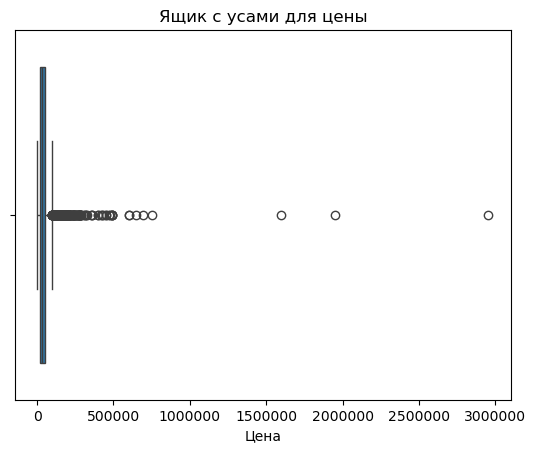

In [19]:
plt.ticklabel_format(style='plain', axis='both')
sns.boxplot(x=cars['price'])
plt.title('Ящик с усами для цены')
plt.xlabel('Цена')
plt.show()

In [20]:
cars[cars['price'] > 1500000]

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
229,Bugatti,Veyron 16.4 Grand Sport,2011,"6,330 mi.",Gasoline,8.0L W16 64V GDI DOHC Twin Turbo,7-Speed Automatic with Auto-Shift,White,White,None reported,Yes,1950995
693,Maserati,Quattroporte Base,2005,"32,000 mi.",Gasoline,394.0HP 4.2L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Red,Beige,At least 1 accident or damage reported,Yes,2954083
3046,Porsche,Carrera GT Base,2005,"4,400 mi.",Gasoline,605.0HP 5.7L 10 Cylinder Engine Gasoline Fuel,6-Speed M/T,Gray,Black,None reported,Yes,1599000


In [21]:
cars['milage'] = cars['milage'].str.replace(' mi.', '').str.replace(',', '').astype(int)

Первая модель, которую я попробую это XGBoostRegressor, очень мощная модель для решения задач регрессии, закодирую признаки через OrdinalEncoder, также для моделей, где имеется мало представителей, я сформировал отдельную категорию - rare_brands

In [22]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [23]:
y_xgb = cars['price']
X_xgb = cars.drop('price', axis=1)

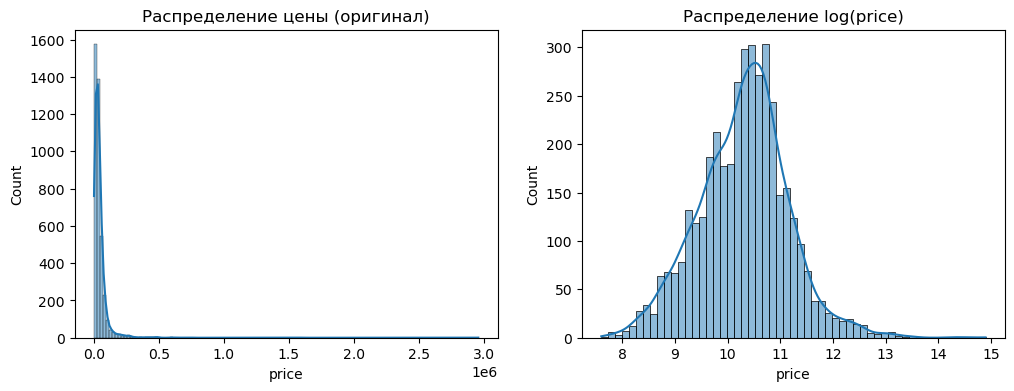

In [24]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(cars['price'], kde=True)
plt.title('Распределение цены (оригинал)')
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(cars['price']), kde=True) 
plt.title('Распределение log(price)')
plt.show()

In [25]:
cars_encoded = cars.copy()
cars_encoded = cars_encoded.drop(['ext_col','int_col','clean_title','model','transmission','engine'], axis=1)
indices_to_drop = cars_encoded[cars_encoded['price'] > 1000000].index
cars_encoded = cars_encoded.drop(indices_to_drop)
counts = cars_encoded['brand'].value_counts()
rare_brands = counts[counts < 5].index
cars_encoded['brand'] = cars_encoded['brand'].replace(rare_brands, 'rare_brands')
y_xgb = cars_encoded['price']
X_xgb = cars_encoded.drop('price', axis=1)
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)
text_cols = X_train_xgb.select_dtypes(include=['object']).columns.tolist()
for col in text_cols:
    ordin = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train_xgb[col] = ordin.fit_transform(X_train_xgb[[col]])
    X_test_xgb[col] = ordin.transform(X_test_xgb[[col]])

In [26]:
model = XGBRegressor()
def r2_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return r2_score(y_true, y_pred)
r2_usd_scorer = make_scorer(r2_usd, greater_is_better=True)
param_grid = {
    'n_estimators': [100, 150, 200, 250, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth': [3, 5, 7, 9]
}
search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring=r2_usd_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_log = np.log1p(y_train_xgb)
y_test_log = np.log1p(y_test_xgb)
search.fit(X_train_xgb,y_train_log)
print('Лучшие параметры:', search.best_params_)
print('Лучший R² (в долларах, по CV):', search.best_score_)
best_model = search.best_estimator_
pred_log = best_model.predict(X_test_xgb)
pred_price = np.expm1(pred_log)
mae = mean_absolute_error(y_test_xgb, pred_price)
mse = mean_squared_error(y_test_xgb, pred_price)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_xgb, pred_price)
r2 = r2_score(y_test_xgb, pred_price)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')
print(f'R2: {r2}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 300}
Лучший R² (в долларах, по CV): 0.6472638131837876
MAE: 12719.787109375
MSE: 1095270272.0
RMSE: 33094.86775921608
MAPE: 0.3051229417324066
R2: 0.5910038948059082


In [27]:
best_params = search.best_params_
print("Лучшие параметры из сетки:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Лучшие параметры из сетки:
learning_rate: 0.1
max_depth: 5
n_estimators: 300


Как мы видим модель очень сильно ошибается на дорогих машинах - ошибка в 456к долларов очень большая

In [28]:
errors = np.abs(y_test_xgb - pred_price)
top_errors = errors.sort_values(ascending=False)
print(top_errors.apply(lambda x: f'{x:,.0f}'))

1508    456,670
1615    431,678
203     390,246
3816    255,845
3179    141,960
         ...   
1177         53
2431         48
2401         33
552          32
2480         28
Name: price, Length: 802, dtype: object


In [29]:
mae_log = mean_absolute_error(y_test_log, pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_log, pred_log))
r2_log = r2_score(y_test_log, pred_log)
print(mae_log, rmse_log, r2_log)

0.30262807887023796 0.4062492372419051 0.741742088289518


Как мы видим самый важный в этом обучении - это пробег машины и год выпуска машины

In [30]:
importance = best_model.feature_importances_  
feature_names = X_train_xgb.columns
print("\nВажности признаков:")
for name, imp in sorted(zip(feature_names, importance), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")


Важности признаков:
milage: 0.447
model_year: 0.268
brand: 0.138
fuel_type: 0.091
accident: 0.056


Отредактируем колонку engine - добавим 3 различных колонки - engine_hp,engine_cylinders,engine_liters,так engine является важным признаком при прогнозировании, но так как он закодирован через OrdinalEncoder и значения кодируются хорошо, если они имеют порядок, в этом случае кодировщик будет выдавать рандомные значения значениям engine, что неправильно, показатель R^2 возрастает при удалении признака из датасета, добавим age_car, закодируем brand через target_encoder, fuel_type через OneHotEncoder. Так как в accident 2 значения закодируем через логическую операцию
Гипотеза 2: После проведения feature engineering и другого кодирования различных признаков - R^2 станет больше, MAE уменьшится и MAPE тоже уменьшится
Гипотеза подтвердилась

In [31]:
import re
cars_tunning = cars.copy()
#пропишем функцию для поиска лошадиных сил, объёма цилиндра, и литража двигателя, сделаем из этого три разные столбика
#и удалим один связующий - engine
def extract_hp(text):
    match = re.search(r'(\d+\.?\d*)\s*HP', str(text))
    return float(match.group(1)) if match else np.nan
def extract_liters(text):
    match = re.search(r'(\d+\.\d+)L', str(text))
    return float(match.group(1)) if match else np.nan
def extract_cylinders(text):
    text = str(text)
    match = re.search(r'[VI](\d+)', text)
    if match:
        return float(match.group(1))
    match = re.search(r'(\d+)\s*Cylinder', text, re.IGNORECASE)
    if match:
        return float(match.group(1))
    return np.nan
def has_turbo(text):
    return int('turbo' in str(text).lower())
cars_tunning['engine_hp'] = cars_tunning['engine'].apply(extract_hp)
cars_tunning['engine_liters'] = cars_tunning['engine'].apply(extract_liters)
cars_tunning['engine_cylinders'] = cars_tunning['engine'].apply(extract_cylinders)
cars_tunning['has_turbo'] = cars_tunning['engine'].apply(has_turbo)
cars_tunning = cars_tunning.drop('engine', axis=1)

In [32]:
cars_tunning.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             4009 non-null   object 
 1   model             4009 non-null   object 
 2   model_year        4009 non-null   int64  
 3   milage            4009 non-null   int64  
 4   fuel_type         4009 non-null   object 
 5   transmission      4009 non-null   object 
 6   ext_col           4009 non-null   object 
 7   int_col           4009 non-null   object 
 8   accident          4009 non-null   object 
 9   clean_title       4009 non-null   object 
 10  price             4009 non-null   int64  
 11  engine_hp         3201 non-null   float64
 12  engine_liters     3613 non-null   float64
 13  engine_cylinders  3569 non-null   float64
 14  has_turbo         4009 non-null   int64  
dtypes: float64(3), int64(4), object(8)
memory usage: 469.9+ KB


In [33]:
from sklearn.preprocessing import TargetEncoder
from sklearn.pipeline import make_pipeline

In [34]:
cars_tunning = cars_tunning.drop(['model','transmission','ext_col','int_col','clean_title'],axis=1)
count_to_drop = cars_tunning[cars_tunning['price'] > 1000000].index
cars_tunning = cars_tunning.drop(count_to_drop)
cars_tunning['age_year'] = 2026 - cars_tunning['model_year']
cars_tunning = cars_tunning.drop(['model_year'],axis=1)

In [35]:
cars_tunning.head()

,brand,milage,fuel_type,accident,price,engine_hp,engine_liters,engine_cylinders,has_turbo,age_year
0,Ford,51000,E85 Flex Fuel,At least 1 accident or damage reported,10300,300.0,3.7,6.0,0,13
1,Hyundai,34742,Gasoline,At least 1 accident or damage reported,38005,NaN,3.8,6.0,0,5
2,Lexus,22372,Gasoline,None reported,54598,NaN,NaN,NaN,0,4
3,INFINITI,88900,Hybrid,None reported,15500,354.0,3.5,6.0,0,11
4,Audi,9835,Gasoline,None reported,34999,NaN,2.0,4.0,1,5


In [36]:
cars_tunning.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4006 entries, 0 to 4008
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   brand             4006 non-null   object 
 1   milage            4006 non-null   int64  
 2   fuel_type         4006 non-null   object 
 3   accident          4006 non-null   object 
 4   price             4006 non-null   int64  
 5   engine_hp         3199 non-null   float64
 6   engine_liters     3610 non-null   float64
 7   engine_cylinders  3567 non-null   float64
 8   has_turbo         4006 non-null   int64  
 9   age_year          4006 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 344.3+ KB


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

In [38]:
y_xgb_tun = cars_tunning['price']
X_xgb_tun = cars_tunning.drop('price', axis=1)
X_train_xgb_tun, X_test_xgb_tun, y_train_xgb_tun, y_test_xgb_tun = train_test_split(X_xgb_tun, y_xgb_tun, test_size=0.2, random_state=42)
#Заполняем пропуски в столбцах медианой по бренду отдельно на train и test
for col in ['engine_hp', 'engine_liters', 'engine_cylinders']:
    X_train_xgb_tun[col] = X_train_xgb_tun.groupby('brand')[col].transform(lambda x: x.fillna(x.median()))
    # для test используем медианы, посчитанные НА TRAIN, а не заново на test
    train_medians = X_train_xgb_tun.groupby('brand')[col].median()
    X_test_xgb_tun[col] = X_test_xgb_tun.apply(
        lambda row: train_medians.get(row['brand'], np.nan) if pd.isna(row[col]) else row[col],
        axis=1
    )
#Заполняем медианой по train-датасету у значений, у которых все три значения NaN
for col in ['engine_hp', 'engine_liters', 'engine_cylinders']:
    train_overall_median = X_train_xgb_tun[col].median()
    X_train_xgb_tun[col] = X_train_xgb_tun[col].fillna(train_overall_median)
    X_test_xgb_tun[col] = X_test_xgb_tun[col].fillna(train_overall_median)
counts_brand = X_train_xgb_tun['brand'].value_counts()
other = counts_brand[counts_brand < 5].index
X_train_xgb_tun['brand'] = X_train_xgb_tun['brand'].replace(other, 'rare_brands')
X_test_xgb_tun['brand'] = X_test_xgb_tun['brand'].replace(other, 'rare_brands')
preprocessor = ColumnTransformer(
    transformers=[
        ('brand_target', TargetEncoder(), ['brand']),
        ('fuel_onehot', OneHotEncoder(handle_unknown='ignore'), ['fuel_type','accident'])],
    remainder='passthrough'
)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators = 150, learning_rate = 0.05,max_depth = 5))
])
y_train_log_tun = np.log1p(y_train_xgb_tun)
y_test_log_tun = np.log1p(y_test_xgb_tun)
pipeline.fit(X_train_xgb_tun,y_train_log_tun)
pred_log_tun = pipeline.predict(X_test_xgb_tun)
pred_price_tun = np.expm1(pred_log_tun)
mae = mean_absolute_error(y_test_xgb_tun, pred_price_tun)
mse = mean_squared_error(y_test_xgb_tun, pred_price_tun)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_xgb_tun, pred_price_tun)
r2 = r2_score(y_test_xgb_tun, pred_price_tun)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')
print(f'R2: {r2}')

MAE: 8919.25390625
MSE: 539928896.0
RMSE: 23236.370112390618
MAPE: 0.21842356026172638
R2: 0.7983796000480652


Модель хорошо предсказывает средний ценовой сегмент(до 150к долларов), но затем из-за недостатка в тренировачной выборке дорогих машин начинает сильно ошибаться, что мы видим из-за маленьких синих точек в правой части графика

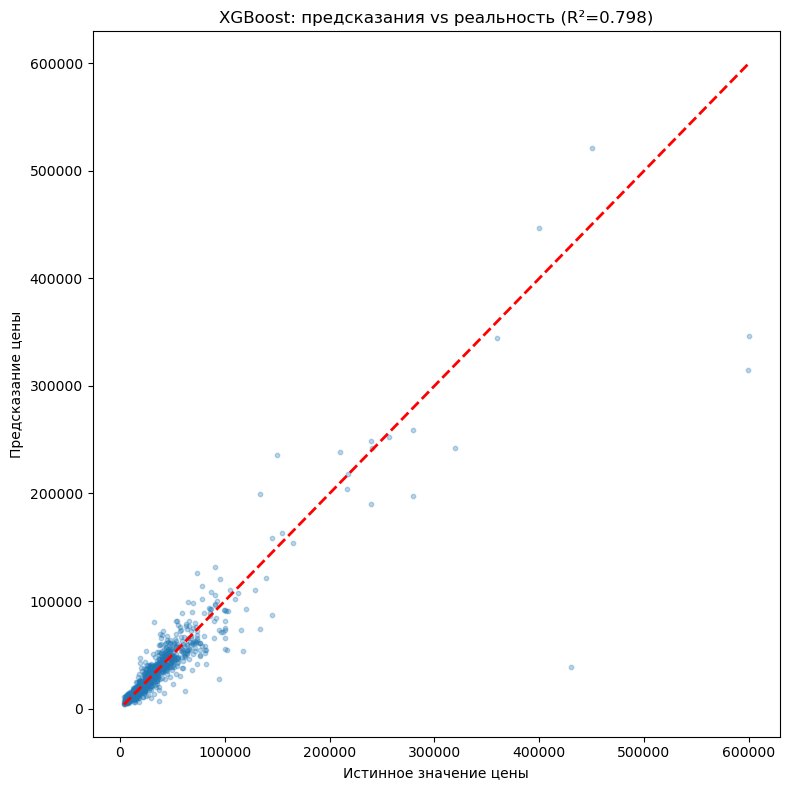

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test_xgb_tun, pred_price_tun, alpha=0.3, s=10)
lims = [y_test_xgb_tun.min(), y_test_xgb_tun.max()]
ax.plot(lims, lims, 'r--', linewidth=2)
ax.set_xlabel('Истинное значение цены')
ax.set_ylabel('Предсказание цены')
ax.set_title(f'XGBoost: предсказания vs реальность (R²={r2_score(y_test_xgb_tun, pred_price_tun):.3f})')
plt.tight_layout()
plt.show()

In [40]:
mae_log_tun = mean_absolute_error(y_test_log_tun, pred_log_tun)
rmse_log_tun = np.sqrt(mean_squared_error(y_test_log_tun, pred_log_tun))
r2_log = r2_score(y_test_log_tun, pred_log_tun)
print(mae_log, rmse_log, r2_log)

0.30262807887023796 0.4062492372419051 0.8575597251011096


Как мы видим самые важные признаки - пробег, возраст и лошадиные силы

In [41]:
importances = pipeline.named_steps['model'].feature_importances_
feature_names_tun = pipeline.named_steps['preprocessor'].get_feature_names_out()
for name, imp in sorted(zip(feature_names_tun, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.3f}")

remainder__milage: 0.354
remainder__age_year: 0.200
remainder__engine_hp: 0.131
brand_target__brand: 0.047
remainder__engine_liters: 0.040
fuel_onehot__fuel_type_Diesel: 0.036
remainder__has_turbo: 0.031
fuel_onehot__fuel_type_Gasoline: 0.029
fuel_onehot__fuel_type_–: 0.028
remainder__engine_cylinders: 0.026
fuel_onehot__fuel_type_electric: 0.022
fuel_onehot__accident_At least 1 accident or damage reported: 0.015
fuel_onehot__fuel_type_Hybrid: 0.013
fuel_onehot__accident_None reported: 0.007
fuel_onehot__fuel_type_E85 Flex Fuel: 0.007
fuel_onehot__fuel_type_not supported: 0.005
fuel_onehot__fuel_type_Plug-In Hybrid: 0.004
fuel_onehot__accident_Unknown: 0.004


Наиболее скорелированными признаками являются engine_cylinders и engine_liters, также сильную связь имеют пробег и возраст, цилиндры и лошадиные силы

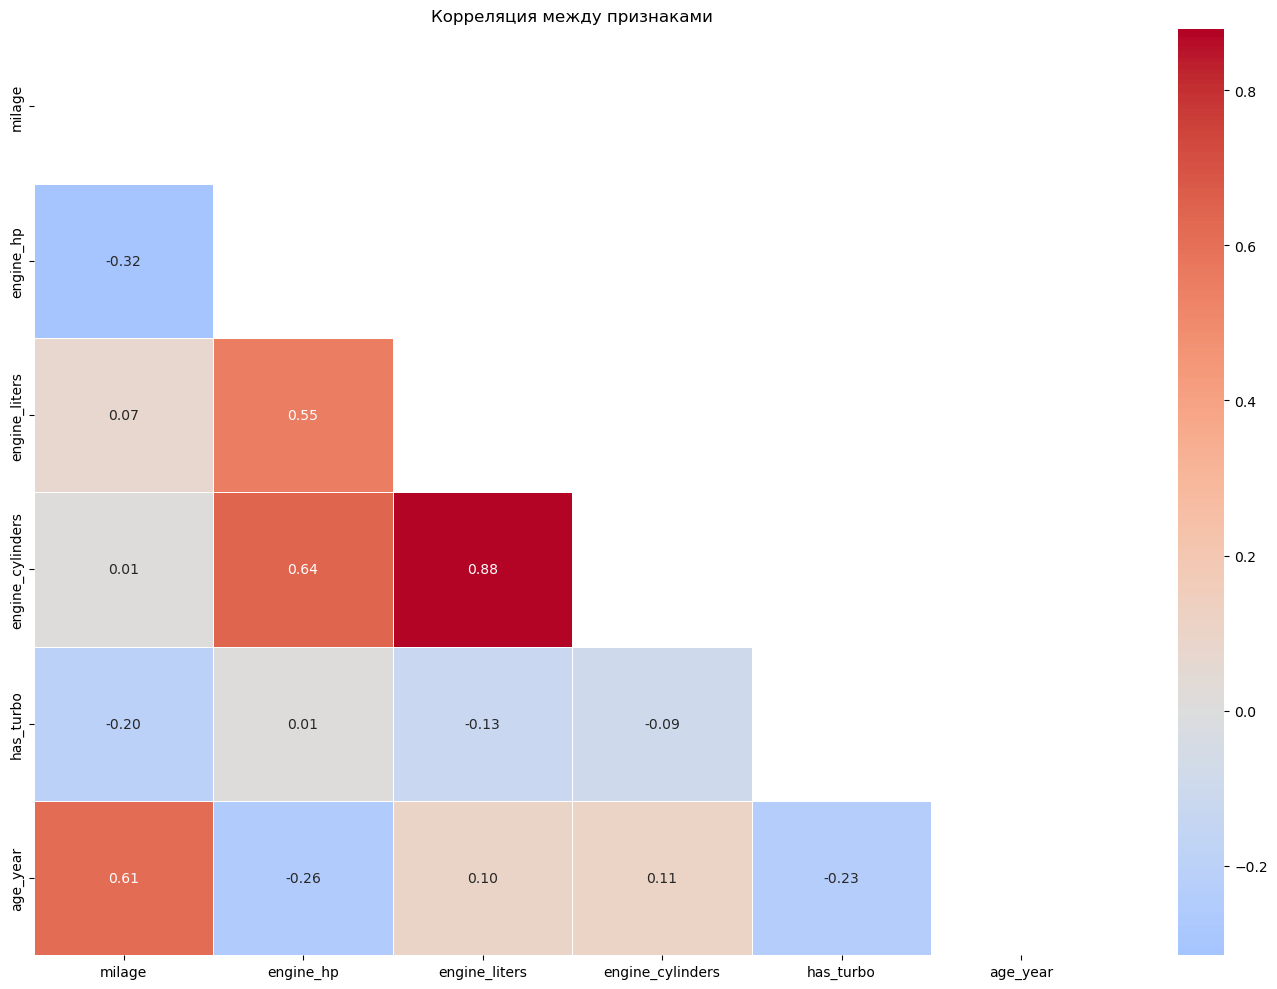

In [42]:
plt.figure(figsize=(14, 10))
numeric_cols = X_train_xgb_tun.select_dtypes(include=np.number).columns.tolist()
corr = X_train_xgb_tun[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Так признаки engine_cylinders и engine_liters имеют между собой большую корреляцию, было бы справедливым удалить их из признаков, но engine hp имеет высокую корреляцию с таргетом, поэтому целесообразнее объединить два признака в один - "engine_power",в автомобильном мире он неинформативен, но чтобы убрать мультколлинеарность, лучше объединить в один, также можно было бы попробовать объединить в себе два самых важных показателя - milage и age_year - пробег за год и посмотреть как поведут себя метрики 
Гипотеза 3: за счёт дополнительного future engineering метрики улучшатся, R^2 будет выше, MAE и MAPE будут ниже
Гипотеза не подтвердилась

In [43]:
print(cars_tunning[['engine_cylinders', 'engine_liters', 'price']].corr())

                  engine_cylinders  engine_liters     price
engine_cylinders          1.000000       0.886499  0.356497
engine_liters             0.886499       1.000000  0.237845
price                     0.356497       0.237845  1.000000


In [44]:
cars_tunning_second = cars_tunning.copy()
cars_tunning_second['engine_power'] = cars_tunning['engine_liters']/cars_tunning['engine_cylinders']
cars_tunning_second.head()
cars_tunning_second['milage_per_year'] = (cars_tunning_second['milage'] / cars_tunning_second['age_year']).round(2)
cars_tunning_second.head()

,brand,milage,fuel_type,accident,price,engine_hp,engine_liters,engine_cylinders,has_turbo,age_year,engine_power,milage_per_year
0,Ford,51000,E85 Flex Fuel,At least 1 accident or damage reported,10300,300.0,3.7,6.0,0,13,0.616667,3923.08
1,Hyundai,34742,Gasoline,At least 1 accident or damage reported,38005,NaN,3.8,6.0,0,5,0.633333,6948.40
2,Lexus,22372,Gasoline,None reported,54598,NaN,NaN,NaN,0,4,NaN,5593.00
3,INFINITI,88900,Hybrid,None reported,15500,354.0,3.5,6.0,0,11,0.583333,8081.82
4,Audi,9835,Gasoline,None reported,34999,NaN,2.0,4.0,1,5,0.500000,1967.00


In [45]:
cars_tunning_second = cars_tunning_second.drop(['milage','age_year','engine_liters','engine_cylinders'],axis=1)
cars_tunning_second.head()

,brand,fuel_type,accident,price,engine_hp,has_turbo,engine_power,milage_per_year
0,Ford,E85 Flex Fuel,At least 1 accident or damage reported,10300,300.0,0,0.616667,3923.08
1,Hyundai,Gasoline,At least 1 accident or damage reported,38005,NaN,0,0.633333,6948.40
2,Lexus,Gasoline,None reported,54598,NaN,0,NaN,5593.00
3,INFINITI,Hybrid,None reported,15500,354.0,0,0.583333,8081.82
4,Audi,Gasoline,None reported,34999,NaN,1,0.500000,1967.00


In [46]:
cars_tunning_second.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4006 entries, 0 to 4008
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            4006 non-null   object 
 1   fuel_type        4006 non-null   object 
 2   accident         4006 non-null   object 
 3   price            4006 non-null   int64  
 4   engine_hp        3199 non-null   float64
 5   has_turbo        4006 non-null   int64  
 6   engine_power     3562 non-null   float64
 7   milage_per_year  4006 non-null   float64
dtypes: float64(3), int64(2), object(3)
memory usage: 281.7+ KB


In [47]:
y_xgb_tun_sec = cars_tunning_second['price']
X_xgb_tun_sec = cars_tunning_second.drop('price', axis=1)
X_train_xgb_tun_sec, X_test_xgb_tun_sec, y_train_xgb_tun_sec, y_test_xgb_tun_sec = train_test_split(X_xgb_tun_sec, y_xgb_tun_sec, test_size=0.2, random_state=42)
for col in ['engine_hp','engine_power']:
    X_train_xgb_tun_sec[col] = X_train_xgb_tun_sec.groupby('brand')[col].transform(lambda x:x.fillna(x.median()))
    train_medians_1 = X_train_xgb_tun_sec.groupby('brand')[col].median()
    X_test_xgb_tun_sec[col] = X_test_xgb_tun_sec.apply(
        lambda row: train_medians_1.get(row['brand'], np.nan) if pd.isna(row[col]) else row[col],
        axis=1
    )
for col in ['engine_hp', 'engine_power']:
    overall_median = X_train_xgb_tun_sec[col].median()
    X_train_xgb_tun_sec[col] = X_train_xgb_tun_sec[col].fillna(overall_median)
    X_test_xgb_tun_sec[col] = X_test_xgb_tun_sec[col].fillna(overall_median)
preprocessor = ColumnTransformer(
    transformers=[
        ('brand_target', TargetEncoder(), ['brand']),
        ('fuel_onehot', OneHotEncoder(handle_unknown='ignore'), ['fuel_type','accident'])],
    remainder='passthrough'
)
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators = 150, learning_rate = 0.05,max_depth = 5))
])
y_train_log_tun_sec = np.log1p(y_train_xgb_tun_sec)
y_test_log_tun_sec = np.log1p(y_test_xgb_tun_sec)
pipeline.fit(X_train_xgb_tun_sec,y_train_log_tun_sec)
pred_log_tun_sec = pipeline.predict(X_test_xgb_tun_sec)
pred_price_tun_sec = np.expm1(pred_log_tun_sec)
mae = mean_absolute_error(y_test_xgb_tun_sec, pred_price_tun_sec)
mse = mean_squared_error(y_test_xgb_tun_sec, pred_price_tun_sec)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test_xgb_tun_sec, pred_price_tun_sec)
r2 = r2_score(y_test_xgb_tun_sec, pred_price_tun_sec)
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'RMSE: {rmse}')
print(f'MAPE: {mape}')
print(f'R2: {r2}')

MAE: 13383.44921875
MSE: 797097728.0
RMSE: 28232.91922561321
MAPE: 0.39746835827827454
R2: 0.7023475170135498


In [48]:
print(X_train_xgb_tun_sec[['engine_hp', 'engine_power']].isna().sum())
print(X_test_xgb_tun_sec[['engine_hp', 'engine_power']].isna().sum())

engine_hp       0
engine_power    0
dtype: int64
engine_hp       0
engine_power    0
dtype: int64


Как мы видим из корреляционной матрицы признаки слабо скоррелированны друг с другом

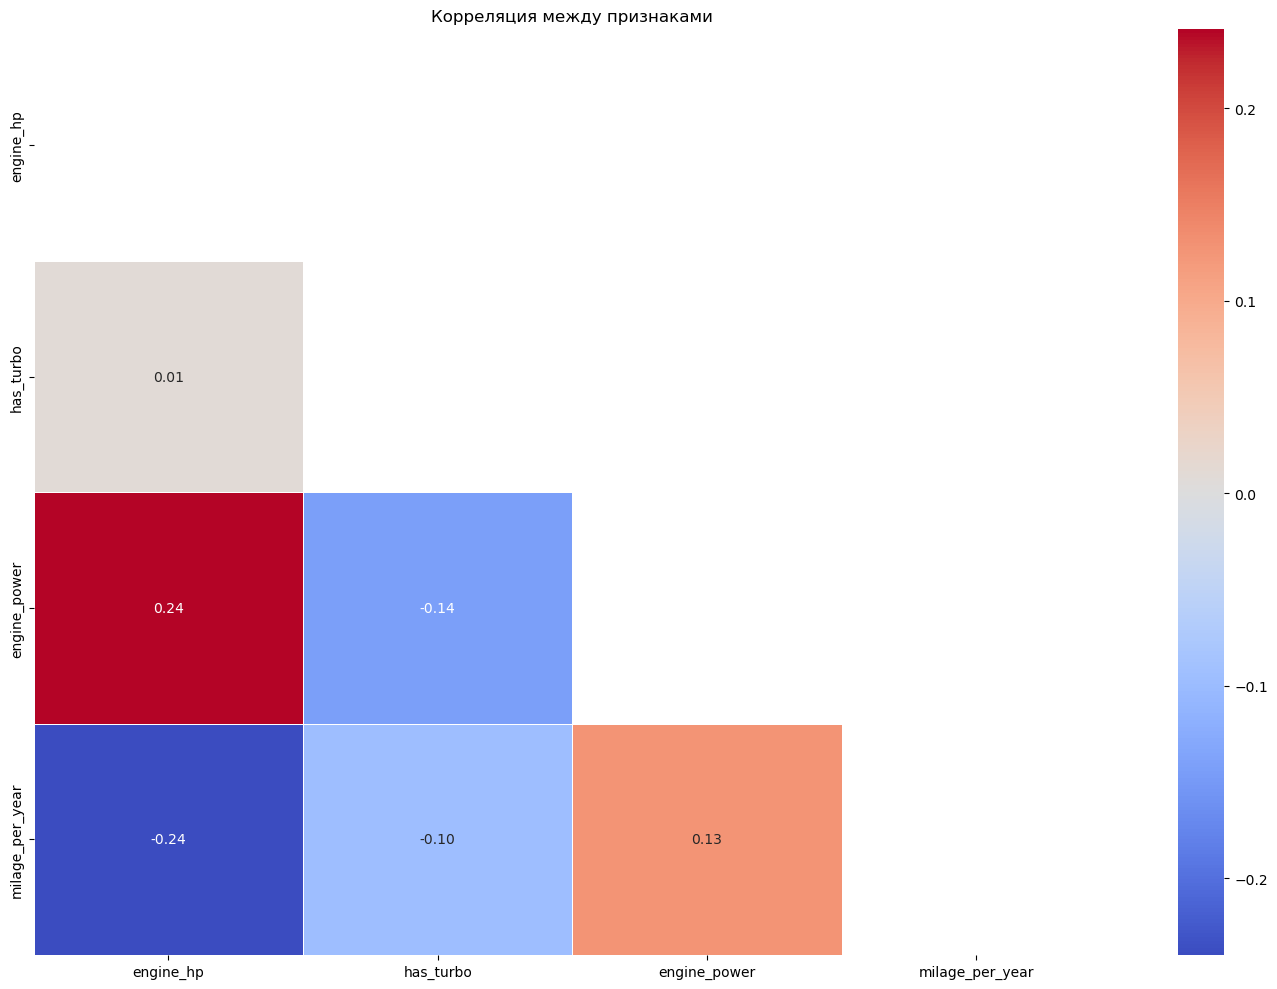

In [49]:
plt.figure(figsize=(14, 10))
numeric_cols = X_train_xgb_tun_sec.select_dtypes(include=np.number).columns.tolist()
corr = X_train_xgb_tun_sec[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

Я буду сравнивать три модели между собой - это RandomForestRegressor,Ridge и XGBoostRegressor,так как в моей модели после второго тюниннга параметров только два признака между собой сильно скореллированы и Ridge как раз-таки не выкинет один из признаков при обучении.Обучать я буду на признаках - cars_tunning, которые показали наивысший R^2
Гипотеза 4: При использвании кросс-валидации, модели будут показывать либо такие же показатели по метрикам, либо метрики будут выше, разбиение буду делать через KFold, проверю на RandomForestRegressor, затем на всех трёх
Подтвердилась частично

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score,KFold, cross_validate

In [51]:
y_others_m = cars_tunning['price'] 
X_others_m = cars_tunning.drop('price', axis=1)
X_train_others_m, X_test_others_m, y_train_others_m, y_test_others_m = train_test_split(
    X_others_m, y_others_m, test_size=0.2, random_state=42
)
# Заполняем пропуски в столбцах медианой по бренду отдельно на train и test
for col in ['engine_hp', 'engine_liters', 'engine_cylinders']:
    X_train_others_m[col] = X_train_others_m.groupby('brand')[col].transform(lambda x: x.fillna(x.median()))
    # для test используем медианы, посчитанные НА TRAIN, а не заново на test
    train_medians = X_train_others_m.groupby('brand')[col].median()
    X_test_others_m[col] = X_test_others_m.apply(
        lambda row: train_medians.get(row['brand'], np.nan) if pd.isna(row[col]) else row[col],
        axis=1
    )
# Заполняем медианой по train-датасету у значений, у которых все три значения NaN
for col in ['engine_hp', 'engine_liters', 'engine_cylinders']:
    train_overall_median = X_train_others_m[col].median()
    X_train_others_m[col] = X_train_others_m[col].fillna(train_overall_median)
    X_test_others_m[col] = X_test_others_m[col].fillna(train_overall_median)
# Группировка редких брендов - считаем ТОЛЬКО по train
counts_brand = X_train_others_m['brand'].value_counts()
other = counts_brand[counts_brand < 5].index
X_train_others_m['brand'] = X_train_others_m['brand'].replace(other, 'rare_brands')
X_test_others_m['brand'] = X_test_others_m['brand'].replace(other, 'rare_brands')
y_train_log_others_m = np.log1p(y_train_others_m)
y_test_log_others_m = np.log1p(y_test_others_m)
preprocessor = ColumnTransformer(
    transformers=[
        ('brand_target', TargetEncoder(), ['brand']),
        ('fuel_onehot', OneHotEncoder(handle_unknown='ignore'), ['fuel_type','accident'])
    ],
    remainder='passthrough'
)
pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42))
])
cv = KFold(n_splits=5, shuffle=True, random_state=123)
def rmse_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
def mae_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return np.mean(np.abs(y_true - y_pred))
def r2_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return r2_score(y_true, y_pred)
r2_usd_scorer = make_scorer(r2_usd, greater_is_better=True)
rmse_usd_scorer = make_scorer(rmse_usd, greater_is_better=False)
mae_usd_scorer = make_scorer(mae_usd, greater_is_better=False)
scoring = {
    'rmse_usd': rmse_usd_scorer,
    'mae_usd': mae_usd_scorer,
    'r2_usd': r2_usd_scorer,
    'r2_log': 'r2' 
}
cv_results = cross_validate(
    pipe, X_train_others_m, y_train_log_others_m,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
rmse_usd_scores = -cv_results['test_rmse_usd']
mae_usd_scores = -cv_results['test_mae_usd']
r2_scores = cv_results['test_r2_log']
print(f"RMSE по фолдам: {rmse_usd_scores}")
print(f"Средний RMSE: {rmse_usd_scores.mean():.2f}")
print(f"Std RMSE: {rmse_usd_scores.std():.2f}")
print(f"MAE по фолдам: {mae_usd_scores}")
print(f"Средний MAE: {mae_usd_scores.mean():.2f} ")
print(f"R² по фолдам: {r2_scores}")
print(f"Средний R²: {r2_scores.mean():.4f}")

RMSE по фолдам: [24804.4415783  25717.28918253 28614.21724865 35476.88104159
 21453.58529906]
Средний RMSE: 27213.28
Std RMSE: 4721.53
MAE по фолдам: [11016.087852   11750.37495156 11795.83654029 12405.29329777
 11419.57620707]
Средний MAE: 11677.43 
R² по фолдам: [0.83891649 0.81514828 0.80058919 0.82813767 0.80806662]
Средний R²: 0.8182


In [52]:
from sklearn.preprocessing import StandardScaler

Применение кросс-валидации дало результат выше по R^2, но есть небольшая разница в средним MAE по фолдам(MAE = 8919 vs средний MAE = 11677)

Гипотеза 5: Модель XGBoostRegressor покажет лучшие показатели по метрикам чем две другие R^2 и MAE XGBoost < R^2 и MAE RandomForest < R^2 и MAE Ridge
Гипотеза подтвердилась частично,std_mean является очень маленьким, что говорит о стабильности модели, R^2 XGBoostRegressor = R^2 RandomForestRegressor,(MAE XGB = 9899 > MAE RandomF = 10222), модель показала хуже результаты при применении кросс-валидации чем при применении одного сплита (R^2 = 0.79 vs R^2 = 0.76),(MAE = 9899 vs MAE = 8919)

In [53]:
def mae_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_absolute_error(y_true, y_pred)
def mape_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return mean_absolute_percentage_error(y_true, y_pred)
def r2_usd(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    return r2_score(y_true, y_pred)
mae_scorer = make_scorer(mae_usd, greater_is_better=False)
mape_scorer = make_scorer(mape_usd, greater_is_better=False)
r2_scorer = make_scorer(r2_usd, greater_is_better=True)
scoring = {'mae': mae_scorer,'mape': mape_scorer, 'r2': r2_scorer}
cv = KFold(n_splits=5, shuffle=True, random_state=42)
models_reg = {
    'Ridge': Ridge(alpha=1),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
}
results = []
for name, model in models_reg.items():
    preprocessor_clean = ColumnTransformer(
        transformers=[
            ('brand_target', TargetEncoder(smooth=10), ['brand']),
            ('fuel_onehot', OneHotEncoder(handle_unknown='ignore'), ['fuel_type','accident']),
        ],
        remainder='passthrough'
    )
    if name == 'Ridge':
        pipe = Pipeline([
            ('preprocessor', preprocessor_clean),
            ('scaler', StandardScaler()),
            ('model', model)
        ])
    else:
        pipe = Pipeline([
            ('preprocessor', preprocessor_clean),
            ('model', model)
        ])
    cv_res = cross_validate(
        pipe,
        X_train_others_m,
        y_train_log_others_m,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    results.append({
        'Model': name,
        'MAE_mean': -cv_res['test_mae'].mean(),
        'MAE_std': cv_res['test_mae'].std(),
        'MAPE_mean': -cv_res['test_mape'].mean(),
        'MAPE_std': cv_res['test_mape'].std(),
        'R2_mean': cv_res['test_r2'].mean(),
    })
pd.DataFrame(results).set_index('Model').round(2)

,MAE_mean,MAE_std,MAPE_mean,MAPE_std,R2_mean
Model,,,,,
Ridge,12913.73,586.03,0.29,0.01,0.60
RandomForest,10222.51,419.09,0.25,0.01,0.76
XGBoost,9899.89,231.82,0.24,0.01,0.76
